# Ergebnisse – Experiment-Summary
- Pro Experiment & Datensatz eine Tabelle (mit `n_runs` bei Exp 1/2/4); Bar-Chart bei Exp 1/2/4, bei Exp 3 SHAP-Tabelle + Bar-Charts (Top-Features und Text vs. numerisch)
- Quelle: alle MLflow-Runs aus `./mlruns`; fehlende/leere Experimente werden übersprungen

In [1]:
import os
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "result_tables"
DIAGRAM_DIR = "diagrams"
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(DIAGRAM_DIR, exist_ok=True)
DS_ABBR = {"fake_jobs": "fj", "airbnb_paris": "airbnb"}

## Runs laden
- Nur vorhandene Experimente aus `./mlruns`; leere/fehlende werden übersprungen

In [2]:
mlflow.set_tracking_uri("file:./mlruns")

experiments = [f"{ds}_experiment_{i}" for ds in ["fake_jobs", "airbnb_paris"] for i in [1, 2, 3, 4, 5]]

parts = []
for name in experiments:
    exp = mlflow.get_experiment_by_name(name)
    if exp is None:
        continue
    runs = mlflow.search_runs([exp.experiment_id])
    if len(runs) == 0:
        continue
    runs["experiment"] = name
    parts.append(runs)

df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(f"{len(df)} Runs aus {len(parts)} Experimenten geladen")

/home/debian/TFM_master_thesis/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


216 Runs aus 8 Experimenten geladen


## Aufbereiten
- Datensatz / Experiment-Nr. / Modellname ableiten; Metrik-Spalten vereinheitlichen

In [3]:
datasets = ["fake_jobs", "airbnb_paris"]

if len(df):
    df["exp_num"] = df["experiment"].str.split("_").str[-1].astype(int)
    df["dataset"] = df["experiment"].str.rsplit("_experiment_", n=1).str[0]
    df["model"] = df["tags.mlflow.runName"] if "tags.mlflow.runName" in df.columns else df["run_id"]
    df = df[df["model"] != "contexttab_fixed"]  # veralteten Run ausschließen
    df = df.rename(columns={"metrics.auprc": "AUPRC", "metrics.auc_roc": "AUROC", "metrics.runtime_s": "runtime_s"})
    for col in ["AUPRC", "AUROC", "runtime_s"]:
        if col not in df.columns:
            df[col] = np.nan
    print("Datensätze:", df["dataset"].unique().tolist(), "| Experimente:", sorted(df["exp_num"].unique()))

Datensätze: ['fake_jobs', 'airbnb_paris'] | Experimente: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Experiment 1 – Unsupervised Outlier Detection
- TFMs (TabPFN unsup., AnoLLM, FoMo-OD) vs. PyOD-Baselines; AUPRC & AUROC je Modell
- Tabelle je Datensatz; je 1 kombinierter Chart für AUPRC, AUROC und Runtime (beide Datensätze, Modelle alphabetisch)

=== Experiment 1 – fake_jobs ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
anollm,0.1005,0.6306,8113.3125,3
iforest,0.0890,0.6125,2.4863,3
autoencoder,0.0816,0.6003,180.9683,3
ecod,0.0745,0.6125,0.4611,3
fomo_od,0.0624,0.6040,0.4328,3
tabpfn_unsup,0.0619,0.5252,356.9191,3
loda,0.0526,0.5185,0.4901,3


=== Experiment 1 – airbnb_paris ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
ecod,0.0920,0.7213,0.6743,3
iforest,0.0832,0.7060,2.3030,3
loda,0.0607,0.5507,0.5940,3
tabpfn_unsup,0.0597,0.6434,1443.7897,3
autoencoder,0.0578,0.6029,188.9135,3
anollm,0.0485,0.5960,9606.8165,3
fomo_od,0.0414,0.5182,0.4001,3


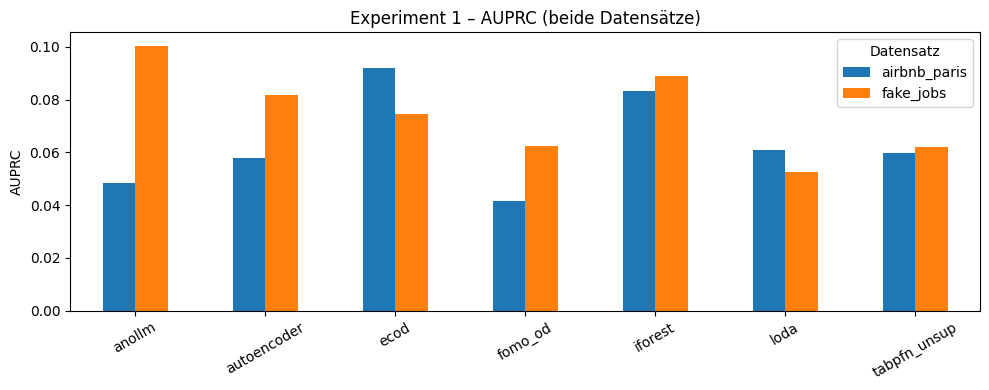

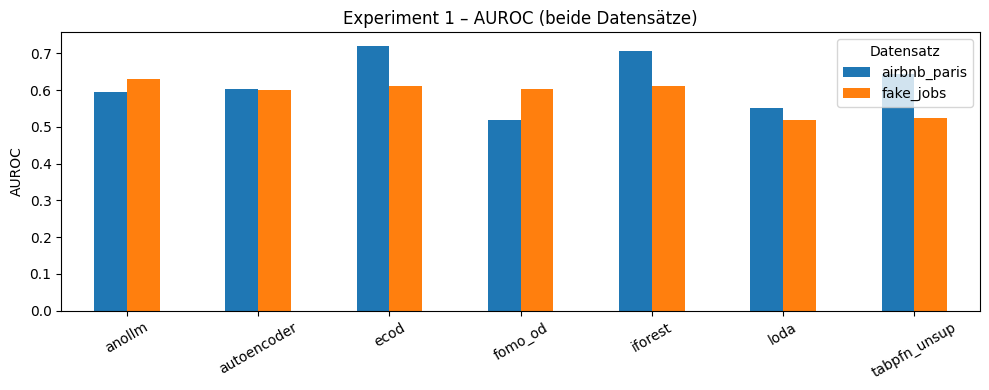

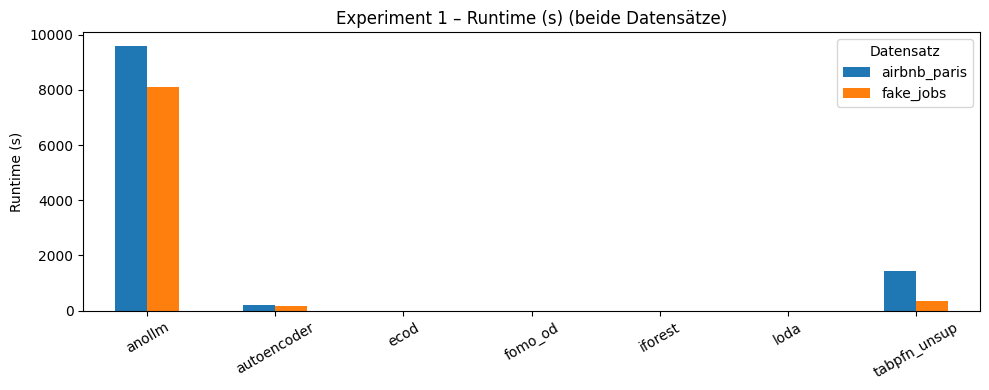

In [4]:
sub = df[df["exp_num"] == 1] if len(df) else df
if not len(sub):
    print("keine Exp-1-Runs")
else:
    # Tabelle je Datensatz
    for ds in datasets:
        s = sub[sub["dataset"] == ds]
        if not len(s):
            continue
        g = s.groupby("model")
        tab = g[["AUPRC", "AUROC", "runtime_s"]].mean()
        tab["n_runs"] = g.size()
        tab = tab.sort_values("AUPRC", ascending=False).round(4)
        tab.to_csv(f"{RESULT_DIR}/exp1_{ds}.csv")
        tab.to_latex(f"{RESULT_DIR}/exp1_{ds}.tex", escape=True, float_format="%.4f", caption=f"Experiment 1 -- Unsupervised Outlier Detection ({ds.replace('_', ' ')}): AUPRC, AUROC und Laufzeit je Modell.", label=f"tab:exp1_{ds}")
        print(f"=== Experiment 1 – {ds} ===")
        display(tab)

    # je 1 Chart (beide Datensätze, Modelle alphabetisch) -> diagrams/
    for metric, label, fname in [("AUPRC", "AUPRC", "aucpr"), ("AUROC", "AUROC", "aucroc"), ("runtime_s", "Runtime (s)", "runtime")]:
        piv = sub.pivot_table(index="model", columns="dataset", values=metric, aggfunc="mean").sort_index()
        ax = piv.plot.bar(figsize=(10, 4), rot=30)
        ax.set_title(f"Experiment 1 – {label} (beide Datensätze)")
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.legend(title="Datensatz")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp1_{fname}.png", facecolor='white', edgecolor='white', dpi=300)
        plt.show()
        plt.close()

## Experiment 2 – Enhanced Baseline-Modelle
- Baselines auf cleaned vs. semantisch vs. enhanced vs. enhanced+semantisch (AUPRC & AUROC je Detektor)
- Je Datensatz je 1 Chart für AUPRC und AUROC
- Hinweis: enhanced ist semi-supervised (Label-Leakage), nicht direkt mit unsupervised vergleichbar

=== Experiment 2 – fake_jobs (AUPRC & n_runs je Detektor × Repräsentation) ===


AUPRC                                                  \
params.representation cleaned enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                                 
autoencoder            0.0816   0.1793         0.0849                  0.0919   
ecod                   0.0745   0.1142         0.1074                  0.0814   
iforest                0.0858   0.1130         0.1453                  0.1083   
loda                   0.0705   0.1503         0.1208                  0.0445   

                                                      n_runs           \
params.representation semantic_pca100 semantic_pca30 cleaned enhanced   
params.detector                                                         
autoencoder                    0.0573         0.0696       3        3   
ecod                           0.0457         0.0580       3        3   
iforest                        0.0560         0.0842       3        3   
loda                           0.0448         0.0384       3        3   

                                                                              \
params.representation enhanced_pca30 enhanced_semantic_pca30 semantic_pca100   
params.detector                                                                
autoencoder                        3                       3               3   
ecod                               3                       3               3   
iforest                            3                       3               3   
loda                               3                       3               3   

                                      
params.representation semantic_pca30  
params.detector                       
autoencoder                        3  
ecod                               3  
iforest                            3  
loda                               3

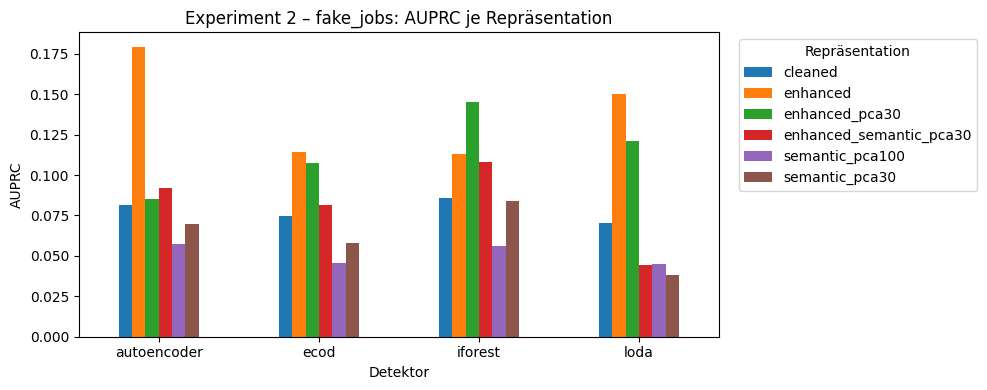

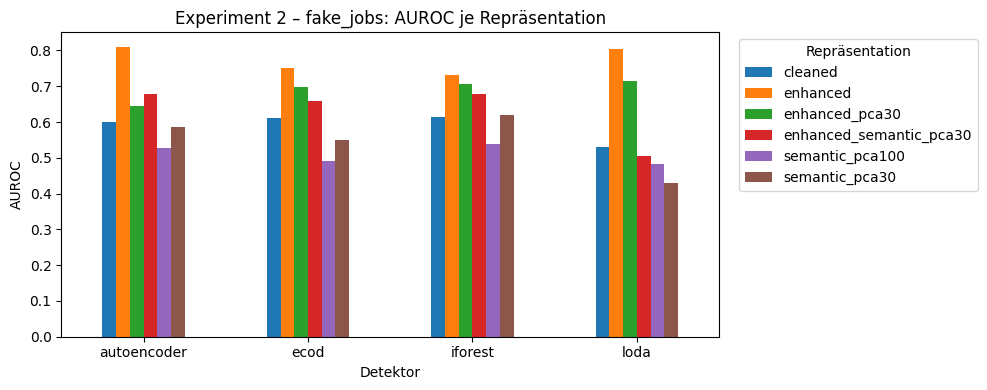

=== Experiment 2 – airbnb_paris (AUPRC & n_runs je Detektor × Repräsentation) ===


AUPRC                                                  \
params.representation cleaned enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                                 
autoencoder            0.0711   0.2296         0.1298                  0.1424   
ecod                   0.1058   0.0598         0.2697                  0.1434   
iforest                0.0867   0.1234         0.2291                  0.1012   
loda                   0.0878   0.0760         0.1919                  0.0627   

                                                      n_runs           \
params.representation semantic_pca100 semantic_pca30 cleaned enhanced   
params.detector                                                         
autoencoder                    0.0433         0.0506       3        3   
ecod                           0.0651         0.0821       3        3   
iforest                        0.0675         0.0786       3        3   
loda                           0.0504         0.0657       3        3   

                                                                              \
params.representation enhanced_pca30 enhanced_semantic_pca30 semantic_pca100   
params.detector                                                                
autoencoder                        3                       3               3   
ecod                               3                       3               3   
iforest                            3                       3               3   
loda                               3                       3               3   

                                      
params.representation semantic_pca30  
params.detector                       
autoencoder                        3  
ecod                               3  
iforest                            3  
loda                               3

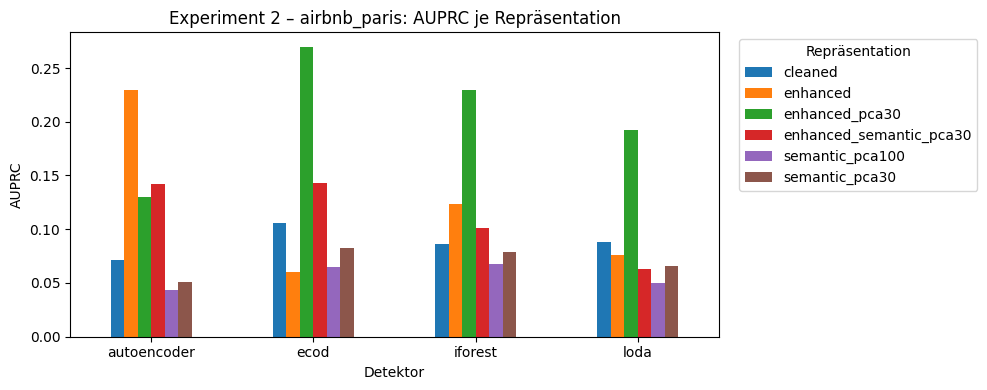

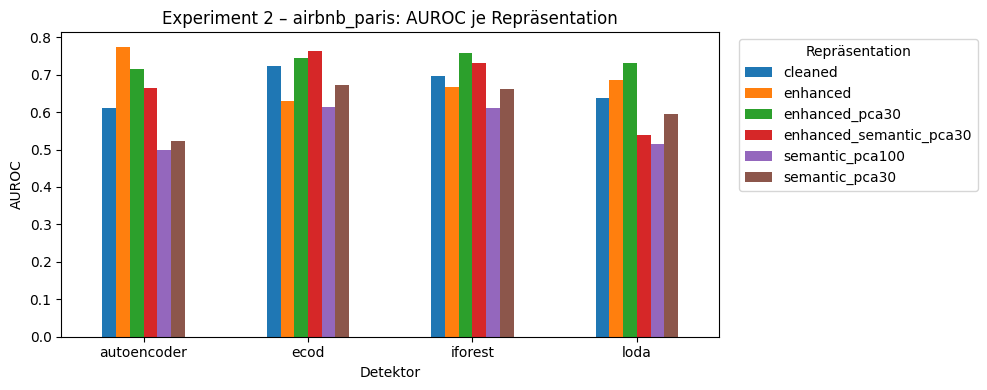

In [5]:
for ds in datasets:
    sub = df[(df["exp_num"] == 2) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-2-Runs")
        continue
    # Tabelle: AUPRC-Mittel + n_runs je Detektor × Repräsentation
    piv = sub.pivot_table(index="params.detector", columns="params.representation", values="AUPRC", aggfunc=["mean", "size"]).round(4)
    piv = piv.rename(columns={"mean": "AUPRC", "size": "n_runs"}, level=0)
    piv.to_csv(f"{RESULT_DIR}/exp2_{ds}.csv")
    piv.to_latex(f"{RESULT_DIR}/exp2_{ds}.tex", escape=True, float_format="%.4f", multicolumn=True, multicolumn_format="c", caption=f"Experiment 2 -- Enhanced Baselines ({ds.replace('_', ' ')}): AUPRC und n\\_runs je Detektor und Repräsentation.", label=f"tab:exp2_{ds}")
    print(f"=== Experiment 2 – {ds} (AUPRC & n_runs je Detektor × Repräsentation) ===")
    display(piv)

    # AUPRC je Detektor × Repräsentation -> diagrams/
    ax = piv["AUPRC"].plot.bar(figsize=(10, 4), rot=0)
    ax.set_title(f"Experiment 2 – {ds}: AUPRC je Repräsentation")
    ax.set_ylabel("AUPRC")
    ax.set_xlabel("Detektor")
    ax.legend(title="Repräsentation", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp2_aucpr_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.show()
    plt.close()

    # AUROC je Detektor × Repräsentation -> diagrams/
    piv_auc = sub.pivot_table(index="params.detector", columns="params.representation", values="AUROC", aggfunc="mean").round(4)
    ax = piv_auc.plot.bar(figsize=(10, 4), rot=0)
    ax.set_title(f"Experiment 2 – {ds}: AUROC je Repräsentation")
    ax.set_ylabel("AUROC")
    ax.set_xlabel("Detektor")
    ax.legend(title="Repräsentation", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp2_aucroc_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.show()
    plt.close()

## Experiment 3 – Semantische Relevanz (SHAP)
- ConTextTab-SHAP: wichtigste Features je Datensatz (Tabelle + Bar-Charts: Top-Features und Text vs. numerisch)

=== Exp 3 – fake_jobs: Top 20 Features (Text + numerisch) ===


,mean_abs_shap,type
company_profile,0.1373,text
has_company_logo,0.0547,numeric
title,0.0503,text
description,0.0354,text
has_questions,0.0310,numeric
requirements,0.0286,text
salary_avg,0.0265,numeric
country,0.0150,numeric
benefits,0.0136,text
industry,0.0116,numeric


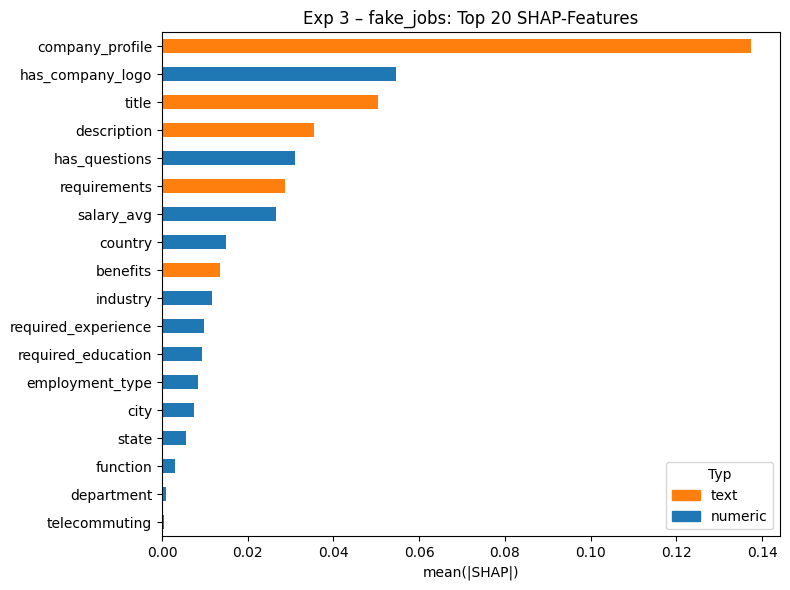

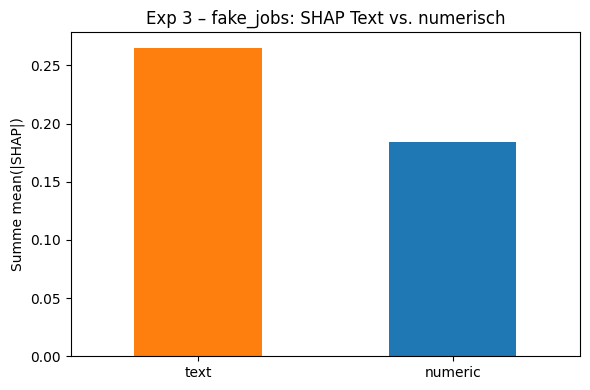

=== Exp 3 – airbnb_paris: Top 20 Features (Text + numerisch) ===


,mean_abs_shap,type
host_tenure_days,0.0352,numeric
name,0.0352,text
estimated_occupancy_l365d,0.0276,numeric
calculated_host_listings_count,0.0265,numeric
host_is_superhost,0.0216,numeric
calculated_host_listings_count_entire_homes,0.0180,numeric
description,0.0170,text
minimum_nights,0.0163,numeric
instant_bookable,0.0162,numeric
accommodates,0.0147,numeric


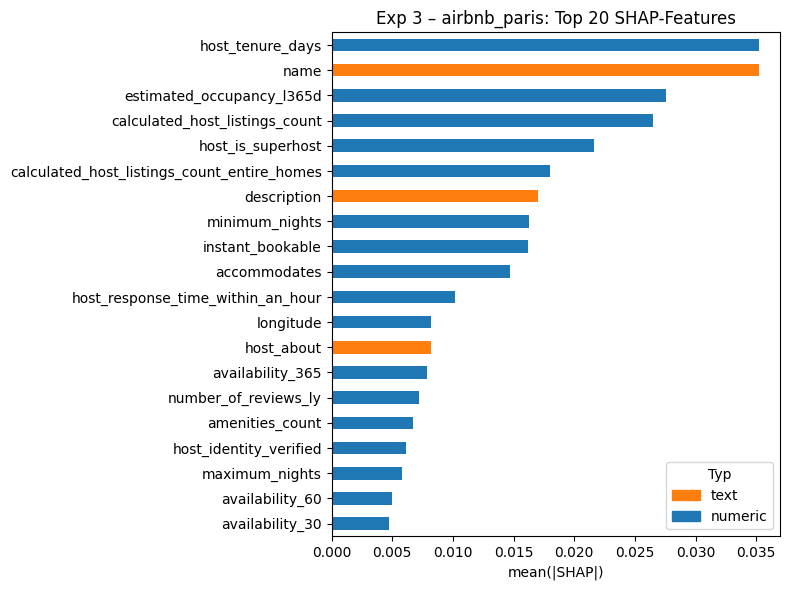

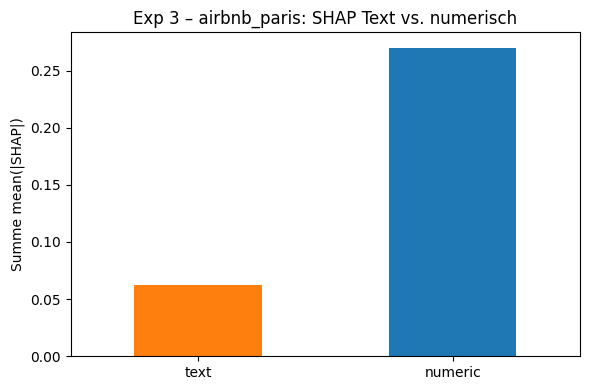

In [10]:
for ds in datasets:
    sub = df[(df["exp_num"] == 3) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        continue
    rel_cols = [c for c in sub.columns if c.startswith("metrics.") and not c.endswith("_total") and sub[c].notna().any()]
    rel = sub.iloc[0][rel_cols].dropna().astype(float)
    rel.index = [c.replace("metrics.", "") for c in rel.index]
    rel_type = pd.Series(["text" if i.startswith("text_") else "numeric" for i in rel.index], index=rel.index)
    top = rel.sort_values(ascending=False).head(20).round(4).to_frame("mean_abs_shap")
    top["type"] = [rel_type[i] for i in top.index]
    top.index = [i.replace("text_", "").replace("num_", "") for i in top.index]
    top.to_csv(f"{RESULT_DIR}/exp3_{ds}.csv")
    top.to_latex(f"{RESULT_DIR}/exp3_{ds}.tex", escape=True, float_format="%.4f", caption=f"Experiment 3 -- Semantische Relevanz ({ds.replace('_', ' ')}): Top-20 SHAP-Features (Text und numerisch).", label=f"tab:exp3_{ds}")
    print(f"=== Exp 3 – {ds}: Top 20 Features (Text + numerisch) ===")
    display(top)

    # bar chart: top features colored by type
    colors = {"text": "tab:orange", "numeric": "tab:blue"}
    ax = top["mean_abs_shap"][::-1].plot.barh(figsize=(8, 6), color=[colors[t] for t in top["type"][::-1]])
    ax.set_title(f"Exp 3 – {ds}: Top 20 SHAP-Features")
    ax.set_xlabel("mean(|SHAP|)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in ["text", "numeric"]]
    ax.legend(handles, ["text", "numeric"], title="Typ")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp3_shap_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.show()
    plt.close()

    # second chart: total SHAP contribution text vs numeric
    by_type = rel.groupby(rel_type).sum().reindex(["text", "numeric"]).fillna(0).round(4)
    ax = by_type.plot.bar(figsize=(6, 4), rot=0, color=[colors[t] for t in by_type.index])
    ax.set_title(f"Exp 3 – {ds}: SHAP Text vs. numerisch")
    ax.set_ylabel("Summe mean(|SHAP|)")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp3_shap_sum_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.show()
    plt.close()

## Experiment 4 – TFMs zur binären Klassifikation
- ConTextTab vs. TabPFN-Klassifikation; AUPRC & AUROC je Modell
- Je Modell zwei `distribution`-Varianten (`original`, `balanced_1to4`) als eigene Runs (`*_original` / `*_balanced_1to4`)
- Tabelle je Datensatz; je 1 kombinierter Chart für AUPRC und AUROC (beide Datensätze, Modelle alphabetisch)

=== Experiment 4 – fake_jobs ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
contexttab_balanced_1to4,0.9144,0.9651,2.7600,3
contexttab_original,0.9039,0.9912,31.6167,3
tabpfn_classification_balanced_1to4,0.8345,0.9439,2.2233,3
tabpfn_classification_original,0.7195,0.9332,4.6000,3


=== Experiment 4 – airbnb_paris ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
tabpfn_classification_balanced_1to4,0.6103,0.8556,2.5267,3
contexttab_balanced_1to4,0.5845,0.8761,2.1400,3
tabpfn_classification_original,0.2030,0.8681,8.0067,3
contexttab_original,0.1816,0.8596,54.7100,3


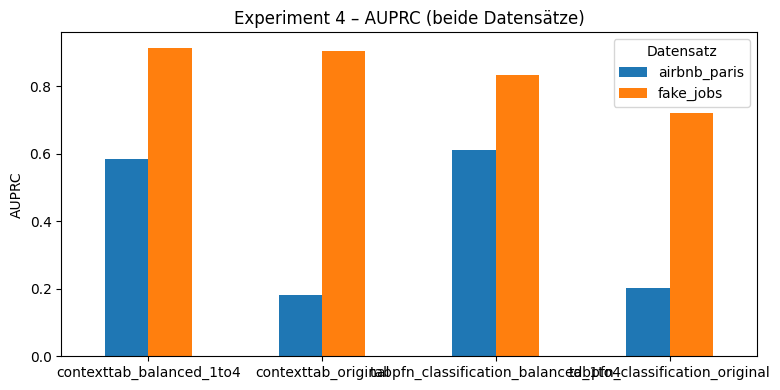

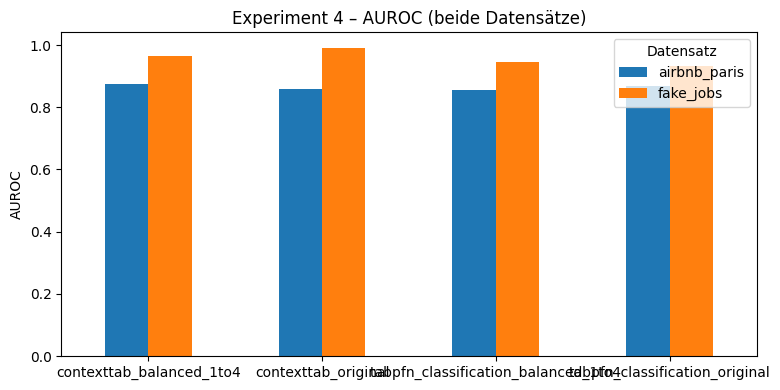

In [7]:
sub = df[df["exp_num"] == 4] if len(df) else df
if not len(sub):
    print("keine Exp-4-Runs")
else:
    # Tabelle je Datensatz
    for ds in datasets:
        s = sub[sub["dataset"] == ds]
        if not len(s):
            continue
        g = s.groupby("model")
        tab = g[["AUPRC", "AUROC", "runtime_s"]].mean()
        tab["n_runs"] = g.size()
        tab = tab.sort_values("AUPRC", ascending=False).round(4)
        tab.to_csv(f"{RESULT_DIR}/exp4_{ds}.csv")
        tab.to_latex(f"{RESULT_DIR}/exp4_{ds}.tex", escape=True, float_format="%.4f", caption=f"Experiment 4 -- TFM-Klassifikation ({ds.replace('_', ' ')}): AUPRC, AUROC und Laufzeit je Modell.", label=f"tab:exp4_{ds}")
        print(f"=== Experiment 4 – {ds} ===")
        display(tab)

    # AUPRC- & AUROC-Chart (beide Datensätze) -> diagrams/
    for metric, label, fname in [("AUPRC", "AUPRC", "aucpr"), ("AUROC", "AUROC", "aucroc")]:
        piv = sub.pivot_table(index="model", columns="dataset", values=metric, aggfunc="mean").sort_index()
        ax = piv.plot.bar(figsize=(8, 4), rot=0)
        ax.set_title(f"Experiment 4 – {label} (beide Datensätze)")
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.legend(title="Datensatz")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp4_{fname}.png", facecolor='white', edgecolor='white', dpi=300)
        plt.show()
        plt.close()

## Experiment 5 – TFM-Erklärbarkeit
- Feature-Attributionen für einen TabPFN-Klassifikator: ShapPFN & ExplainerPFN vs. KernelSHAP (Baseline)
- Je Explainer: Fidelity vs. KernelSHAP (Spearman + Cosine) und Laufzeit; KernelSHAP selbst = Referenz

In [8]:
for ds in datasets:
    sub = df[(df["exp_num"] == 5) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-5-Runs")
        continue
    runs_total = sub.groupby("model").size()
    latest = sub.sort_values("start_time").groupby("model").tail(1).set_index("model")  # nur der neueste Run je Modell
    cols = {"metrics.pearson_vs_kernelshap": "pearson_vs_KernelSHAP",
            "metrics.spearman_vs_kernelshap": "spearman_vs_KernelSHAP",
            "metrics.cosine_vs_kernelshap": "cosine_vs_KernelSHAP",
            "runtime_s": "runtime_s"}
    tab = pd.DataFrame(index=latest.index)
    for src, dst in cols.items():
        tab[dst] = latest[src] if src in latest.columns else np.nan
    tab["runs_total"] = runs_total
    # KernelSHAP (Referenz) zuerst, dann nach Fidelity absteigend
    sp = tab["spearman_vs_KernelSHAP"]
    order = sorted(tab.index, key=lambda m: (m != "kernelshap", -(sp[m] if pd.notna(sp[m]) else -np.inf)))
    tab = tab.loc[order].round(4)
    tab.to_csv(f"{RESULT_DIR}/exp5_{ds}.csv")
    tab.to_latex(f"{RESULT_DIR}/exp5_{ds}.tex", escape=True, float_format="%.4f", caption=f"Experiment 5 -- TFM-Erklärbarkeit ({ds.replace('_', ' ')}): Explainer-Fidelity vs. KernelSHAP (neuester Run).", label=f"tab:exp5_{ds}")
    print(f"=== Experiment 5 – {ds}: Explainer-Fidelity vs. KernelSHAP (neuester Run) ===")
    display(tab)
    fid = tab["spearman_vs_KernelSHAP"].dropna()
    if len(fid):
        ax = fid.plot.bar(figsize=(7, 4), rot=0)
        ax.set_title(f"Experiment 5 – {ds}: Fidelity (Spearman vs. KernelSHAP)")
        ax.set_ylabel("Spearman")
        ax.set_xlabel("")
        ax.axhline(0, color="black", linewidth=0.8)
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp5_fidelity_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
        plt.show()
        plt.close()

fake_jobs: keine Exp-5-Runs
airbnb_paris: keine Exp-5-Runs
